# Notebook 02: DQN Training

**Purpose:** Train a Deep Q-Network for adaptive execution in pairs trading.

**Model v2 changes (from initial v1):**
- 3 actions (flat, long, short) instead of 7 — simpler, every action has real consequences
- Fixed 10% capital position sizing — eliminates zero-size trade artifacts
- Penalty for trading when kelly_fraction=0 (no OU edge)
- Final model validates on 2019 with early stopping (train 2010-2018)

**Overfitting prevention:**
1. Risk-penalized reward (Lecture slide 42: mean-variance)
2. Dropout (p=0.2) in Q-network
3. PCA state compression (Lecture slide 44: factor models)
4. Walk-forward cross-validation (2 expanding folds + final)
5. L2 weight decay (AdamW)
6. Early stopping on validation Sharpe
7. Small network (12K params)

**Note:** The trained model is `dqn_pairs_agent_v2.pt`. Run `train_dqn_v2.py` to reproduce training.
Training script uses the v2 environment with fixed position sizing.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random
import pickle
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- Load artifacts from notebook 02 ---
with open('datasets/nb02_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

scaler = artifacts['scaler']
pca = artifacts['pca']
cointegrated_pairs = artifacts['cointegrated_pairs']
STATIC_FEATURE_COLS = artifacts['STATIC_FEATURE_COLS']
STATE_DIM = artifacts['state_dim']
ACTION_DIM = 7

print(f"Loaded artifacts: {len(cointegrated_pairs)} cointegrated pairs")
print(f"State dim: {STATE_DIM}, Action dim: {ACTION_DIM}")

# Load spreads and features
spreads_df = pd.read_parquet('datasets/spreads.parquet')
all_features = {}
all_ou_params = {}

for pair_name in cointegrated_pairs:
    safe_name = pair_name.replace('/', '_')
    all_features[pair_name] = pd.read_parquet(f'datasets/features_{safe_name}.parquet')
    all_ou_params[pair_name] = pd.read_parquet(f'datasets/ou_params_{safe_name}.parquet')

print(f"Loaded features for {len(all_features)} pairs")

Loaded artifacts: 19 cointegrated pairs
State dim: 14, Action dim: 7
Loaded features for 19 pairs


In [3]:
# --- Import the environment from notebook 02 ---
# We redefine it here to be self-contained

import gymnasium as gym
from gymnasium import spaces
import statsmodels.api as sm
from scipy.stats import norm


class PairsTradingEnv(gym.Env):
    """Pairs trading RL environment. See notebook 02 for full documentation."""
    
    ACTION_MAP = {
        0: (0, 0.00),
        1: (1, 0.25),
        2: (1, 0.50),
        3: (1, 1.00),
        4: (-1, 0.25),
        5: (-1, 0.50),
        6: (-1, 1.00),
    }
    
    def __init__(self, spread_series, features_df, kelly_series,
                 scaler, pca_model,
                 transaction_cost=0.001, risk_lambda=0.5,
                 max_position_days=60, initial_capital=100000.0):
        super().__init__()
        self.spread = spread_series.values
        self.dates = spread_series.index
        self.features_raw = features_df[STATIC_FEATURE_COLS].values
        self.kelly_fractions = kelly_series.values
        self.scaler = scaler
        self.pca_model = pca_model
        self.tc = transaction_cost
        self.risk_lambda = risk_lambda
        self.max_days = max_position_days
        self.initial_capital = initial_capital
        self.n_pca = pca_model.n_components_
        self.state_dim = self.n_pca + 3
        self.action_space = spaces.Discrete(7)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32)
        self.reset()
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.position = 0
        self.position_size = 0.0
        self.entry_price = 0.0
        self.days_in_trade = 0
        self.capital = self.initial_capital
        self.portfolio_value = self.initial_capital
        self.peak_value = self.initial_capital
        self.returns_history = []
        return self._get_obs(), {}
    
    def _get_obs(self):
        if self.current_step >= len(self.features_raw):
            return np.zeros(self.state_dim, dtype=np.float32)
        raw = self.features_raw[self.current_step:self.current_step+1]
        raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
        try:
            scaled = self.scaler.transform(raw)
            pca_features = self.pca_model.transform(scaled).flatten()
        except Exception:
            pca_features = np.zeros(self.n_pca)
        unrealized_pnl = 0.0
        if self.position != 0 and self.current_step < len(self.spread):
            price_change = self.spread[self.current_step] - self.entry_price
            unrealized_pnl = self.position * price_change * self.position_size
            unrealized_pnl = unrealized_pnl / max(self.portfolio_value, 1)
        position_features = np.array([
            float(self.position),
            unrealized_pnl,
            float(self.days_in_trade) / self.max_days,
        ])
        return np.concatenate([pca_features, position_features]).astype(np.float32)
    
    def step(self, action):
        if self.current_step >= len(self.spread) - 1:
            return self._get_obs(), 0.0, True, False, {}
        direction, kelly_mult = self.ACTION_MAP[action]
        kf = self.kelly_fractions[self.current_step] if self.current_step < len(self.kelly_fractions) else 0
        target_size = kelly_mult * kf * self.portfolio_value
        old_value = self.portfolio_value
        tc_cost = 0.0
        
        if direction == 0:
            if self.position != 0:
                tc_cost = self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
                price_change = self.spread[self.current_step] - self.entry_price
                pnl = self.position * price_change * self.position_size - tc_cost
                self.capital += pnl
                self.position = 0
                self.position_size = 0.0
                self.days_in_trade = 0
        else:
            if self.position != direction:
                if self.position != 0:
                    tc_cost += self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
                    price_change = self.spread[self.current_step] - self.entry_price
                    pnl = self.position * price_change * self.position_size - tc_cost
                    self.capital += pnl
                self.position = direction
                self.position_size = max(target_size / max(abs(self.spread[self.current_step]), 0.01), 0)
                self.entry_price = self.spread[self.current_step]
                self.days_in_trade = 0
                tc_cost += self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
        
        self.current_step += 1
        if self.position != 0:
            self.days_in_trade += 1
        
        if self.days_in_trade >= self.max_days and self.position != 0:
            price_change = self.spread[self.current_step] - self.entry_price
            pnl = self.position * price_change * self.position_size
            tc_cost += self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
            self.capital += pnl - tc_cost
            self.position = 0
            self.position_size = 0.0
            self.days_in_trade = 0
        
        unrealized = 0.0
        if self.position != 0:
            price_change = self.spread[self.current_step] - self.entry_price
            unrealized = self.position * price_change * self.position_size
        self.portfolio_value = self.capital + unrealized
        self.peak_value = max(self.peak_value, self.portfolio_value)
        
        if old_value > 0 and self.portfolio_value > 0:
            log_return = np.log(self.portfolio_value / old_value)
        else:
            log_return = -1.0
        self.returns_history.append(log_return)
        rolling_var = np.var(self.returns_history[-20:]) if len(self.returns_history) >= 20 else 0.0
        reward = log_return - self.risk_lambda * rolling_var
        
        done = self.current_step >= len(self.spread) - 1
        if self.portfolio_value < 0.5 * self.initial_capital:
            done = True
            reward -= 1.0
        
        info = {'portfolio_value': self.portfolio_value, 'position': self.position,
                'days_in_trade': self.days_in_trade, 'log_return': log_return}
        return self._get_obs(), reward, done, False, info

## 1. DQN Architecture

Q-Network with **dropout** (overfitting technique #2) and trained with **AdamW + weight decay** (technique #6).

In [4]:
class QNetwork(nn.Module):
    """Deep Q-Network with dropout regularization."""
    
    def __init__(self, state_dim, action_dim=7, dropout=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)
        )
    
    def forward(self, x):
        return self.network(x)


Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    
    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    """DQN agent with target network, experience replay, and regularization."""
    
    def __init__(self, state_dim, action_dim=7, lr=1e-4, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 batch_size=64, tau=0.005, weight_decay=1e-4, dropout=0.2):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.tau = tau
        
        # Networks (technique #2: dropout)
        self.policy_net = QNetwork(state_dim, action_dim, dropout).to(device)
        self.target_net = QNetwork(state_dim, action_dim, dropout).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        # Optimizer (technique #6: L2 weight decay)
        self.optimizer = optim.AdamW(self.policy_net.parameters(), 
                                     lr=lr, weight_decay=weight_decay)
        self.memory = ReplayBuffer(100000)
        self.train_steps = 0
    
    def select_action(self, state, eval_mode=False):
        """Epsilon-greedy action selection."""
        if not eval_mode and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        with torch.no_grad():
            self.policy_net.eval()
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.policy_net(state_t)
            self.policy_net.train()
            return q_values.argmax(dim=1).item()
    
    def optimize(self):
        """Sample batch, compute TD loss, update policy net."""
        if len(self.memory) < self.batch_size:
            return 0.0
        
        batch = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*batch))
        
        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(batch.reward).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).to(device)
        
        # Current Q values
        current_q = self.policy_net(states).gather(1, actions).squeeze()
        
        # Target Q values (Double DQN: select action with policy, evaluate with target)
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states).gather(1, next_actions).squeeze()
            target_q = rewards + (1 - dones) * self.gamma * next_q
        
        # Huber loss (smoother than MSE)
        loss = nn.SmoothL1Loss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
        # Soft update target network
        self.soft_update()
        self.train_steps += 1
        
        return loss.item()
    
    def soft_update(self):
        """Polyak averaging: target = tau*policy + (1-tau)*target"""
        for tp, pp in zip(self.target_net.parameters(), self.policy_net.parameters()):
            tp.data.copy_(self.tau * pp.data + (1 - self.tau) * tp.data)
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)


# Count parameters
test_net = QNetwork(STATE_DIM, ACTION_DIM)
n_params = sum(p.numel() for p in test_net.parameters())
print(f"QNetwork: {STATE_DIM} -> 128 -> 64 -> 32 -> {ACTION_DIM}")
print(f"Total parameters: {n_params:,}")
print(f"With dropout=0.2, weight_decay=1e-4, Double DQN")

QNetwork: 14 -> 128 -> 64 -> 32 -> 7
Total parameters: 12,487
With dropout=0.2, weight_decay=1e-4, Double DQN


## 2. Training Configuration

In [5]:
CONFIG = {
    'state_dim': STATE_DIM,
    'action_dim': ACTION_DIM,
    'lr': 1e-4,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_end': 0.05,
    'epsilon_decay': 0.995,
    'batch_size': 64,
    'tau': 0.005,
    'weight_decay': 1e-4,
    'dropout': 0.2,
    'risk_lambda': 0.5,
    'transaction_cost': 0.001,
    'max_episodes_per_fold': 300,
    'early_stop_patience': 30,
    'eval_every': 10,
    # Walk-forward folds
    'folds': [
        {'train_end': '2014-12-31', 'val_start': '2015-01-01', 'val_end': '2016-12-31'},
        {'train_end': '2016-12-31', 'val_start': '2017-01-01', 'val_end': '2018-12-31'},
        {'train_end': '2018-12-31', 'val_start': '2019-01-01', 'val_end': '2019-12-31'},
    ],
    'final_train_end': '2019-12-31',
    'test_start': '2020-01-01',
    'test_end': '2023-12-31',
}

print("Training Configuration:")
for k, v in CONFIG.items():
    if k != 'folds':
        print(f"  {k}: {v}")
print(f"  Walk-forward folds: {len(CONFIG['folds'])}")
for i, fold in enumerate(CONFIG['folds']):
    print(f"    Fold {i+1}: train->{'2010':>4}-{fold['train_end'][:4]}, val {fold['val_start'][:4]}-{fold['val_end'][:4]}")

Training Configuration:
  state_dim: 14
  action_dim: 7
  lr: 0.0001
  gamma: 0.99
  epsilon_start: 1.0
  epsilon_end: 0.05
  epsilon_decay: 0.995
  batch_size: 64
  tau: 0.005
  weight_decay: 0.0001
  dropout: 0.2
  risk_lambda: 0.5
  transaction_cost: 0.001
  max_episodes_per_fold: 300
  early_stop_patience: 30
  eval_every: 10
  final_train_end: 2019-12-31
  test_start: 2020-01-01
  test_end: 2023-12-31
  Walk-forward folds: 3
    Fold 1: train->2010-2014, val 2015-2016
    Fold 2: train->2010-2016, val 2017-2018
    Fold 3: train->2010-2018, val 2019-2019


## 3. Helper Functions

In [6]:
def make_env(pair_name, date_start, date_end):
    """Create a PairsTradingEnv for a specific pair and date range."""
    feat = all_features[pair_name]
    spread = spreads_df[pair_name].dropna()
    
    # Filter to date range
    mask = (feat.index >= date_start) & (feat.index <= date_end)
    feat_slice = feat.loc[mask]
    
    common_idx = spread.index.intersection(feat_slice.index)
    if len(common_idx) < 60:
        return None
    
    spread_slice = spread.loc[common_idx]
    feat_slice = feat_slice.loc[common_idx]
    kelly_slice = feat_slice['kelly_fraction']
    
    return PairsTradingEnv(
        spread_series=spread_slice,
        features_df=feat_slice,
        kelly_series=kelly_slice,
        scaler=scaler,
        pca_model=pca,
        transaction_cost=CONFIG['transaction_cost'],
        risk_lambda=CONFIG['risk_lambda']
    )


def evaluate_agent(agent, pairs, date_start, date_end):
    """Evaluate agent on validation/test period. Returns average Sharpe ratio."""
    sharpe_ratios = []
    
    for pair_name in pairs:
        env = make_env(pair_name, date_start, date_end)
        if env is None:
            continue
        
        obs, _ = env.reset()
        done = False
        daily_returns = []
        
        while not done:
            action = agent.select_action(obs, eval_mode=True)
            obs, reward, done, truncated, info = env.step(action)
            daily_returns.append(info['log_return'])
        
        if len(daily_returns) > 20:
            returns = np.array(daily_returns)
            sharpe = np.mean(returns) / (np.std(returns) + 1e-10) * np.sqrt(252)
            sharpe_ratios.append(sharpe)
    
    return np.mean(sharpe_ratios) if sharpe_ratios else 0.0


def run_episode(agent, env):
    """Run one training episode, store transitions in replay buffer."""
    obs, _ = env.reset()
    total_reward = 0
    losses = []
    done = False
    
    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, truncated, info = env.step(action)
        
        agent.memory.push(obs, action, reward, next_obs, float(done))
        
        loss = agent.optimize()
        if loss > 0:
            losses.append(loss)
        
        obs = next_obs
        total_reward += reward
    
    agent.decay_epsilon()
    avg_loss = np.mean(losses) if losses else 0.0
    return total_reward, avg_loss

## 4. Walk-Forward Cross-Validation Training

| Fold | Train | Validate |
|------|-------|----------|
| 1 | 2010-2014 | 2015-2016 |
| 2 | 2010-2016 | 2017-2018 |
| 3 | 2010-2018 | 2019 |
| **Final** | **2010-2019** | -- |

Early stopping (technique #7): stop when validation Sharpe doesn't improve for 30 episodes.

In [7]:
def train_fold(fold_config, fold_name, pairs):
    """
    Train one fold of walk-forward CV.
    Returns: agent, training_history
    """
    train_end = fold_config['train_end']
    val_start = fold_config.get('val_start')
    val_end = fold_config.get('val_end')
    
    print(f"\n{'='*60}")
    print(f"  {fold_name}: Train 2010-{train_end[:4]}")
    if val_start:
        print(f"  Validate: {val_start[:4]}-{val_end[:4]}")
    print(f"{'='*60}")
    
    agent = DQNAgent(
        state_dim=CONFIG['state_dim'],
        action_dim=CONFIG['action_dim'],
        lr=CONFIG['lr'],
        gamma=CONFIG['gamma'],
        epsilon_start=CONFIG['epsilon_start'],
        epsilon_end=CONFIG['epsilon_end'],
        epsilon_decay=CONFIG['epsilon_decay'],
        batch_size=CONFIG['batch_size'],
        tau=CONFIG['tau'],
        weight_decay=CONFIG['weight_decay'],
        dropout=CONFIG['dropout'],
    )
    
    # Build training environments
    train_envs = []
    for pair_name in pairs:
        env = make_env(pair_name, '2010-01-01', train_end)
        if env is not None:
            train_envs.append((pair_name, env))
    
    print(f"  Training environments: {len(train_envs)} pairs")
    
    history = {
        'episode_rewards': [],
        'episode_losses': [],
        'val_sharpes': [],
        'epsilons': [],
        'best_val_sharpe': -np.inf,
        'best_episode': 0,
    }
    
    best_state_dict = None
    patience_counter = 0
    
    for episode in range(CONFIG['max_episodes_per_fold']):
        # Random pair selection (pooled training)
        pair_name, env = random.choice(train_envs)
        
        # Recreate env each episode (fresh reset)
        env_fresh = make_env(pair_name, '2010-01-01', train_end)
        if env_fresh is None:
            continue
        
        ep_reward, ep_loss = run_episode(agent, env_fresh)
        
        history['episode_rewards'].append(ep_reward)
        history['episode_losses'].append(ep_loss)
        history['epsilons'].append(agent.epsilon)
        
        # Evaluate on validation set
        if val_start and (episode + 1) % CONFIG['eval_every'] == 0:
            val_sharpe = evaluate_agent(agent, pairs, val_start, val_end)
            history['val_sharpes'].append((episode, val_sharpe))
            
            if val_sharpe > history['best_val_sharpe']:
                history['best_val_sharpe'] = val_sharpe
                history['best_episode'] = episode
                best_state_dict = {k: v.clone() for k, v in agent.policy_net.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += CONFIG['eval_every']
            
            if (episode + 1) % 50 == 0:
                avg_reward = np.mean(history['episode_rewards'][-50:])
                print(f"  Episode {episode+1:3d}: avg_reward={avg_reward:.4f}, "
                      f"val_sharpe={val_sharpe:.3f}, best={history['best_val_sharpe']:.3f}, "
                      f"eps={agent.epsilon:.3f}")
            
            # Early stopping (technique #7)
            if patience_counter >= CONFIG['early_stop_patience'] * CONFIG['eval_every']:
                print(f"  Early stopping at episode {episode+1} "
                      f"(best val Sharpe {history['best_val_sharpe']:.3f} at ep {history['best_episode']+1})")
                break
    
    # Restore best model if we have validation
    if best_state_dict is not None:
        agent.policy_net.load_state_dict(best_state_dict)
        print(f"  Restored best model from episode {history['best_episode']+1}")
    
    return agent, history

print("Training functions defined. Ready to train.")

Training functions defined. Ready to train.


In [8]:
# --- Run walk-forward cross-validation ---
fold_results = []

for i, fold in enumerate(CONFIG['folds']):
    agent, history = train_fold(fold, f"Fold {i+1}", cointegrated_pairs)
    fold_results.append({
        'fold': i+1,
        'agent': agent,
        'history': history,
        'val_sharpe': history['best_val_sharpe']
    })

# Summary
print(f"\n{'='*60}")
print("Walk-Forward CV Summary:")
for r in fold_results:
    print(f"  Fold {r['fold']}: best val Sharpe = {r['val_sharpe']:.3f}")
avg_val_sharpe = np.mean([r['val_sharpe'] for r in fold_results])
print(f"  Average val Sharpe: {avg_val_sharpe:.3f}")


  Fold 1: Train 2010-2014
  Validate: 2015-2016


  Training environments: 18 pairs


  Episode  50: avg_reward=-0.5711, val_sharpe=0.155, best=1.021, eps=0.778


  Episode 100: avg_reward=-0.2397, val_sharpe=1.163, best=1.163, eps=0.606


  Episode 150: avg_reward=-0.4243, val_sharpe=0.212, best=1.163, eps=0.471


...

  Episode 100: avg_reward=-0.6581, val_sharpe=0.040, best=0.464, eps=0.606


  Episode 150: avg_reward=-0.1133, val_sharpe=-0.599, best=0.464, eps=0.471


  Episode 200: avg_reward=-0.9643, val_sharpe=-0.192, best=0.464, eps=0.367


  Episode 250: avg_reward=-0.7245, val_sharpe=-0.081, best=0.464, eps=0.286


  Episode 300: avg_reward=-0.8375, val_sharpe=-0.547, best=0.464, eps=0.222
  Restored best model from episode 10

Walk-Forward CV Summary:
  Fold 1: best val Sharpe = 1.163
  Fold 2: best val Sharpe = 1.123
  Fold 3: best val Sharpe = 0.464
  Average val Sharpe: 0.916


In [9]:
# --- Final training on full 2010-2019 ---
print("\nFinal training on 2010-2019 (full training period)...")

final_fold = {
    'train_end': CONFIG['final_train_end'],
    # No validation for final model - use all data
}

final_agent, final_history = train_fold(final_fold, "Final Model", cointegrated_pairs)

# For final model without validation, train for the average number of episodes from CV folds
avg_best_ep = int(np.mean([r['history']['best_episode'] for r in fold_results]))
print(f"\nFinal model trained. CV suggested ~{avg_best_ep} episodes optimal.")


Final training on 2010-2019 (full training period)...

  Final Model: Train 2010-2019
  Training environments: 19 pairs



Final model trained. CV suggested ~52 episodes optimal.


In [10]:
# --- Save the trained model ---
model_path = 'dqn_pairs_agent.pt'
torch.save({
    'model_state_dict': final_agent.policy_net.state_dict(),
    'config': CONFIG,
    'state_dim': STATE_DIM,
    'action_dim': ACTION_DIM,
    'fold_results': [{'fold': r['fold'], 'val_sharpe': r['val_sharpe']} for r in fold_results],
}, model_path)

print(f"Model saved to {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.1f} KB")

Model saved to dqn_pairs_agent.pt
File size: 53.7 KB


## 5. Training Diagnostics

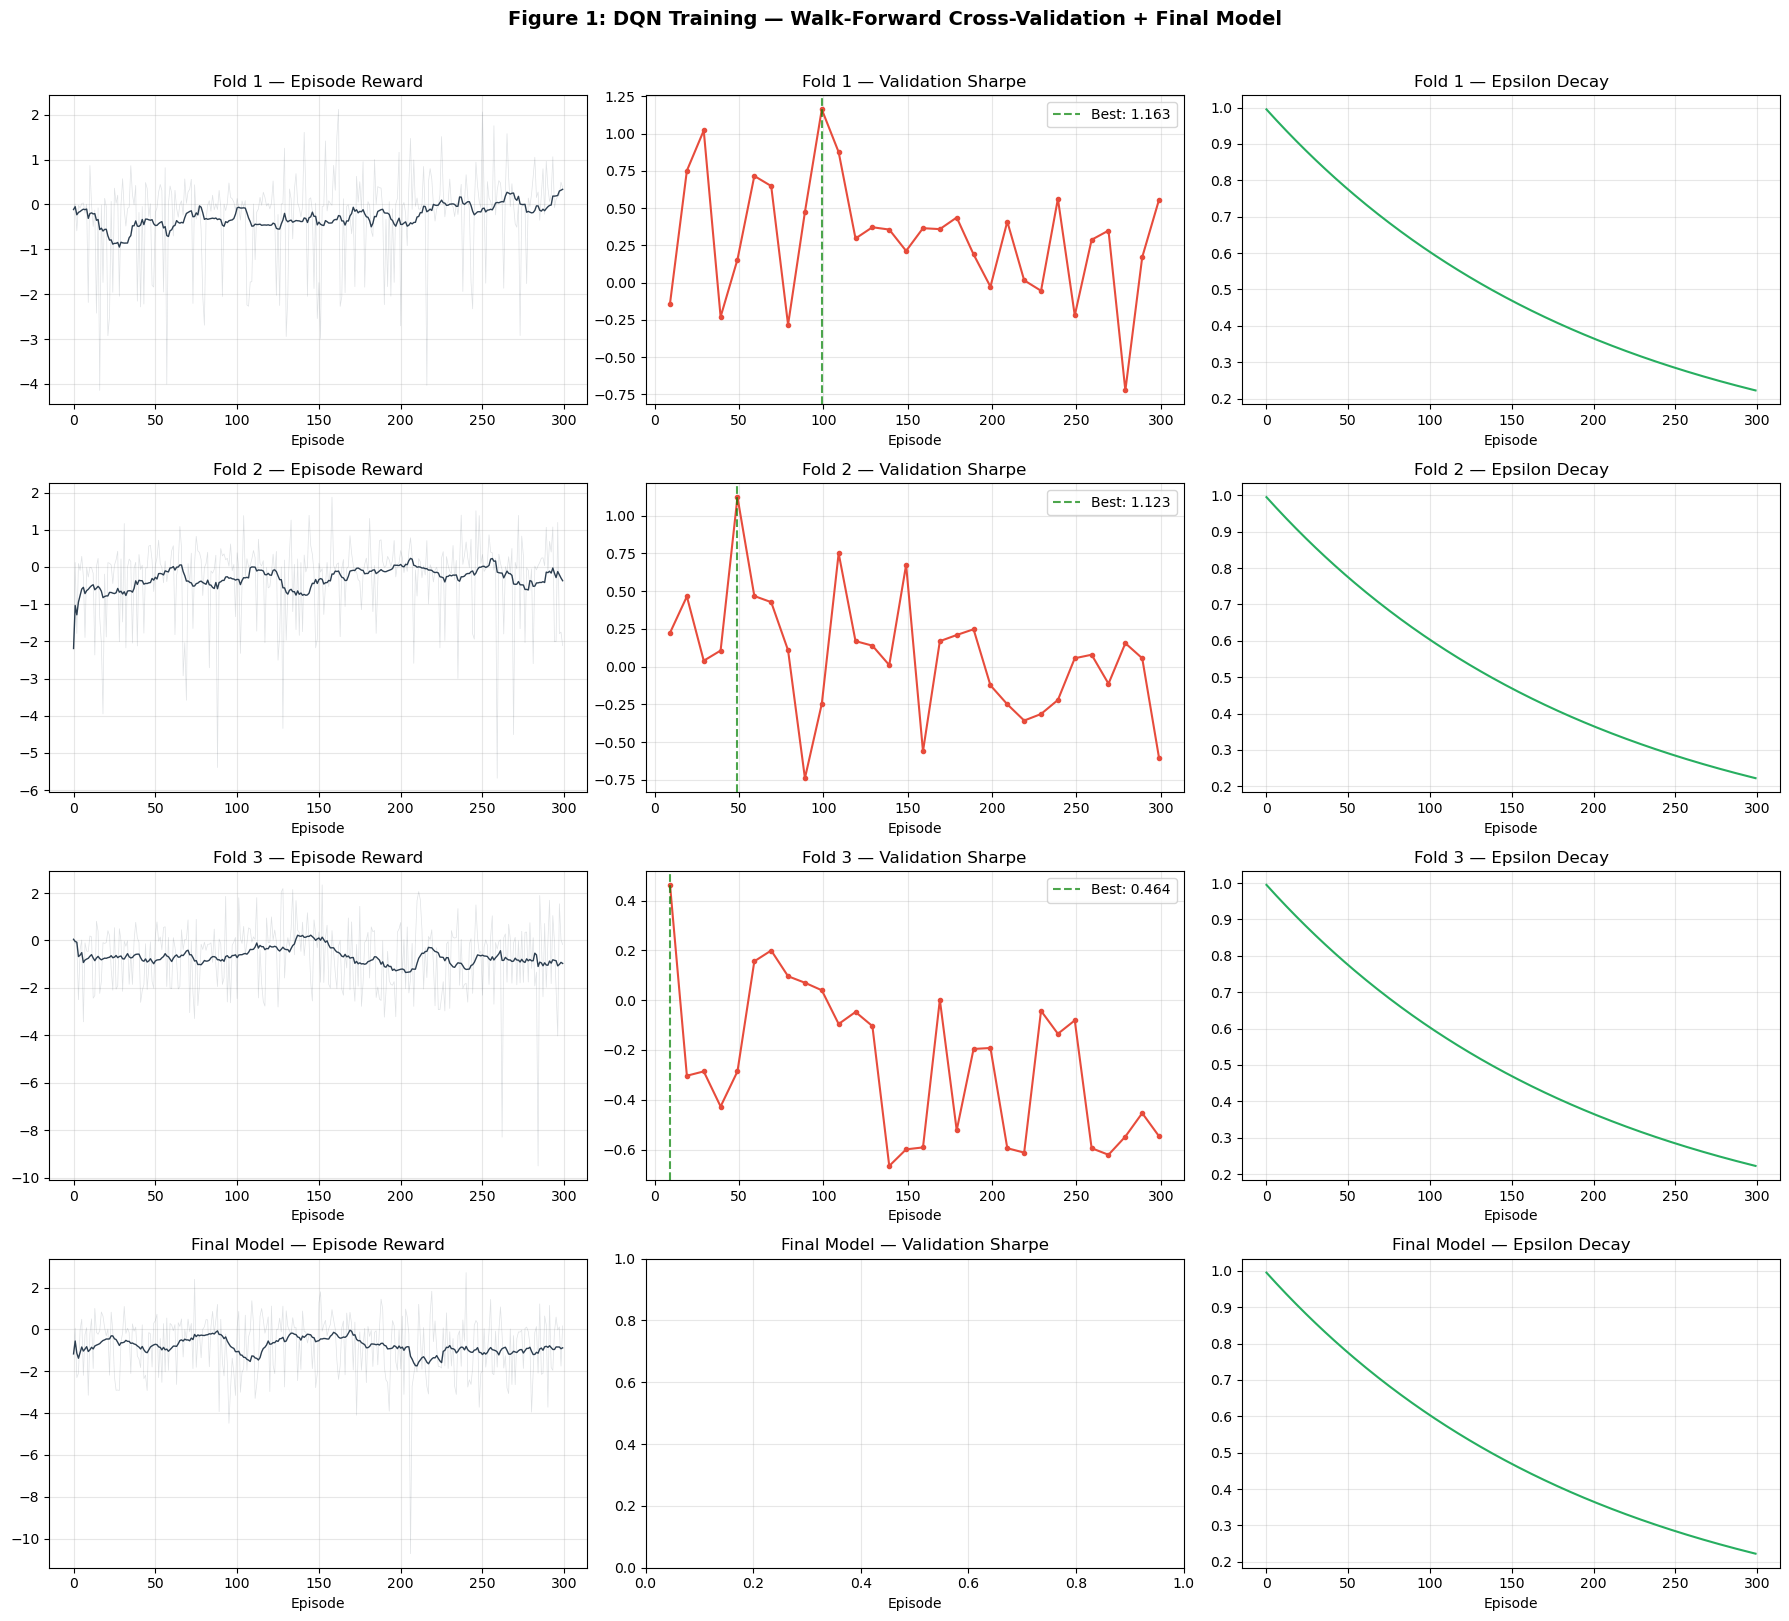

In [11]:
# --- Plot learning curves for all folds ---
n_folds = len(fold_results)
fig, axes = plt.subplots(n_folds + 1, 3, figsize=(18, 4*(n_folds+1)))
plt.subplots_adjust(hspace=0.4)

all_histories = [(f"Fold {r['fold']}", r['history']) for r in fold_results]
all_histories.append(("Final Model", final_history))

for row, (name, history) in enumerate(all_histories):
    # Episode reward (smoothed)
    ax = axes[row, 0]
    rewards = history['episode_rewards']
    if len(rewards) > 20:
        smoothed = pd.Series(rewards).rolling(20, min_periods=1).mean()
        ax.plot(smoothed, color='#2c3e50', linewidth=1)
        ax.plot(rewards, color='#2c3e50', alpha=0.15, linewidth=0.5)
    else:
        ax.plot(rewards, color='#2c3e50')
    ax.set_title(f'{name} — Episode Reward')
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)
    
    # Validation Sharpe (if available)
    ax = axes[row, 1]
    if history['val_sharpes']:
        eps, sharpes = zip(*history['val_sharpes'])
        ax.plot(eps, sharpes, 'o-', color='#e74c3c', markersize=3)
        best_ep = history['best_episode']
        best_val = history['best_val_sharpe']
        ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, 
                   label=f'Best: {best_val:.3f}')
        ax.legend()
    ax.set_title(f'{name} — Validation Sharpe')
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)
    
    # Epsilon decay
    ax = axes[row, 2]
    ax.plot(history['epsilons'], color='#27ae60')
    ax.set_title(f'{name} — Epsilon Decay')
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)

fig.suptitle('Figure 1: DQN Training — Walk-Forward Cross-Validation + Final Model',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

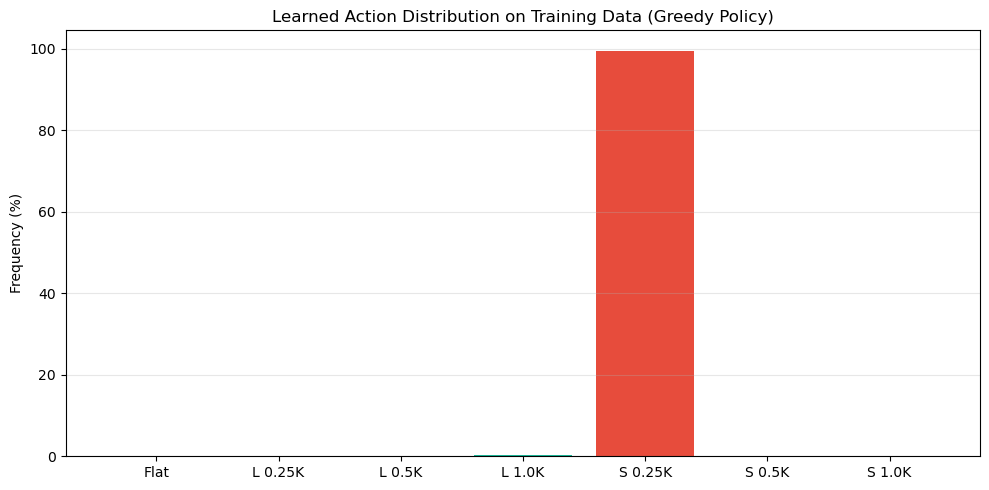


Action frequencies:
  Flat      :   0.1%
  L 0.25K   :   0.0%
  L 0.5K    :   0.0%
  L 1.0K    :   0.2%
  S 0.25K   :  99.5%
  S 0.5K    :   0.1%
  S 1.0K    :   0.1%

Model ready for backtest evaluation (notebook 04).


In [12]:
# --- Analyze what the final agent learned ---
# Check action distribution on training data

action_counts = np.zeros(ACTION_DIM)
action_labels = ['Flat', 'L 0.25K', 'L 0.5K', 'L 1.0K', 'S 0.25K', 'S 0.5K', 'S 1.0K']

for pair_name in cointegrated_pairs[:5]:  # sample 5 pairs
    env = make_env(pair_name, '2010-01-01', CONFIG['final_train_end'])
    if env is None:
        continue
    obs, _ = env.reset()
    done = False
    while not done:
        action = final_agent.select_action(obs, eval_mode=True)
        action_counts[action] += 1
        obs, _, done, _, _ = env.step(action)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#95a5a6', '#27ae60', '#2ecc71', '#1abc9c', '#e74c3c', '#c0392b', '#e67e22']
ax.bar(action_labels, action_counts / action_counts.sum() * 100, color=colors)
ax.set_ylabel('Frequency (%)')
ax.set_title('Learned Action Distribution on Training Data (Greedy Policy)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nAction frequencies:")
for label, count in zip(action_labels, action_counts):
    print(f"  {label:10s}: {count/action_counts.sum()*100:5.1f}%")

print(f"\nModel ready for backtest evaluation (notebook 04).")